In [1]:
import pandas as pd
df=pd.read_csv('anomalies.csv')

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28481 entries, 0 to 28480
Data columns (total 32 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Time     28481 non-null  float64
 1   V1       28481 non-null  float64
 2   V2       28481 non-null  float64
 3   V3       28481 non-null  float64
 4   V4       28481 non-null  float64
 5   V5       28481 non-null  float64
 6   V6       28481 non-null  float64
 7   V7       28481 non-null  float64
 8   V8       28481 non-null  float64
 9   V9       28481 non-null  float64
 10  V10      28481 non-null  float64
 11  V11      28481 non-null  float64
 12  V12      28481 non-null  float64
 13  V13      28481 non-null  float64
 14  V14      28481 non-null  float64
 15  V15      28481 non-null  float64
 16  V16      28481 non-null  float64
 17  V17      28481 non-null  float64
 18  V18      28481 non-null  float64
 19  V19      28481 non-null  float64
 20  V20      28481 non-null  float64
 21  V21      284

In [3]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,anomaly
0,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,1
1,7.0,-0.644269,1.417964,1.074380,-0.492199,0.948934,0.428118,1.120631,-3.807864,0.615375,...,-1.015455,0.057504,-0.649709,-0.415267,-0.051634,-1.206921,-1.085339,40.80,0,1
2,12.0,-2.791855,-0.327771,1.641750,1.767473,-0.136588,0.807596,-0.422911,-1.907107,0.755713,...,0.222182,1.020586,0.028317,-0.232746,-0.235557,-0.164778,-0.030154,58.80,0,1
3,14.0,-5.401258,-5.450148,1.186305,1.736239,3.049106,-1.763406,-1.559738,0.160842,1.233090,...,0.984460,2.458589,0.042119,-0.481631,-0.621272,0.392053,0.949594,46.80,0,1
4,36.0,-1.004929,-0.985978,-0.038039,3.710061,-6.631951,5.122103,4.371691,-2.006868,-0.278736,...,-0.381671,0.969719,0.019445,0.570923,0.333278,0.857373,-0.075538,1402.95,0,1


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold

In [6]:
target_cols = ['Class', 'anomaly']
features = df.drop(columns=target_cols)

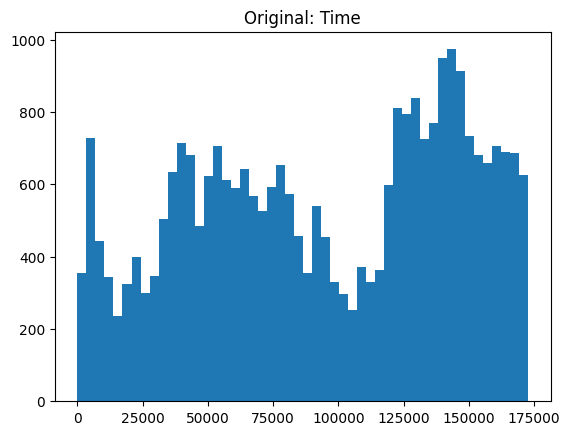

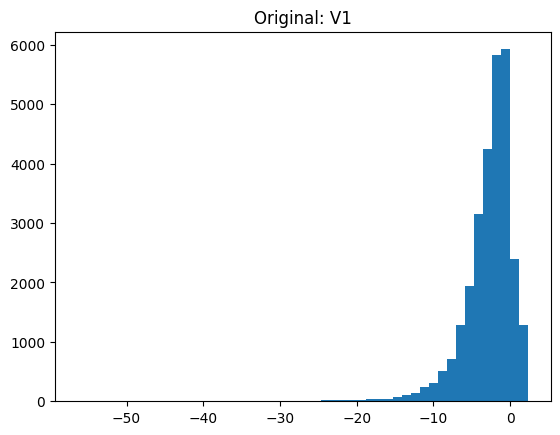

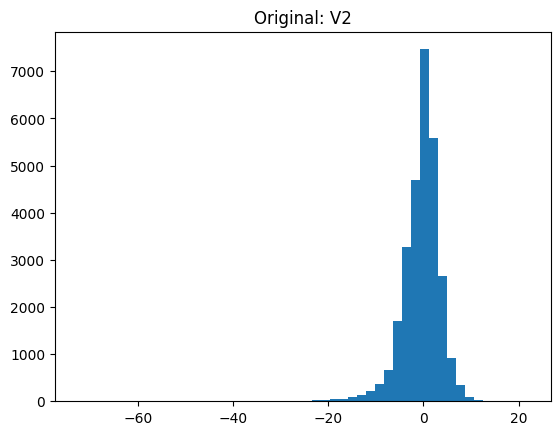

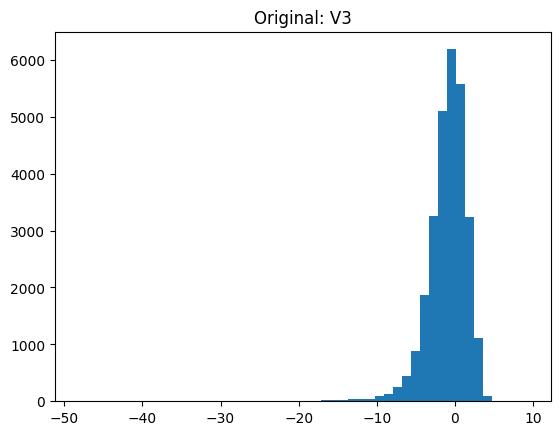

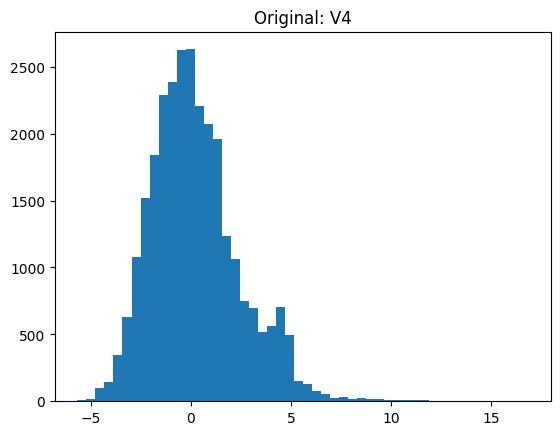

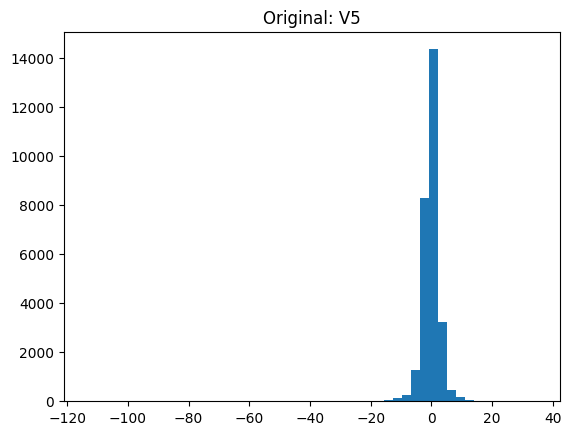

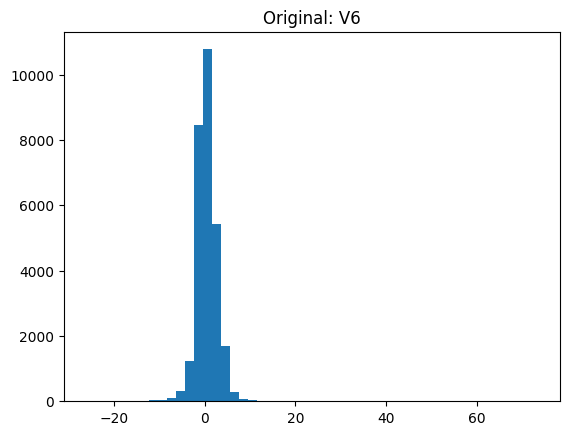

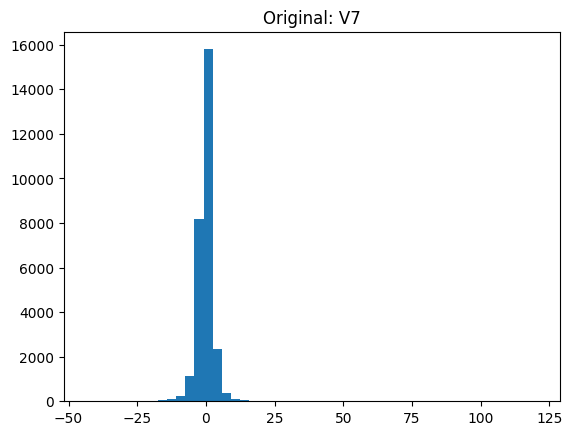

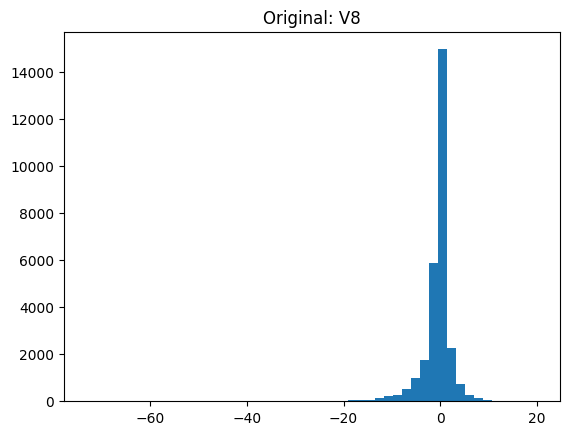

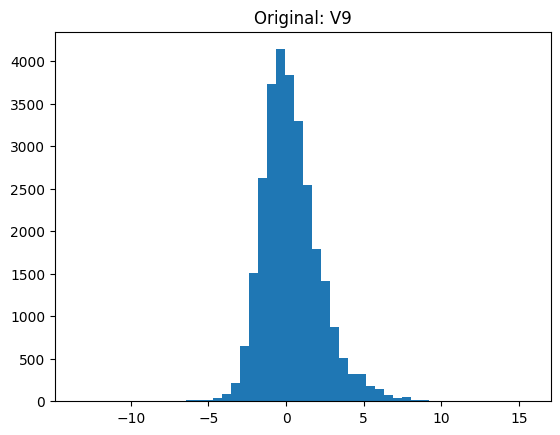

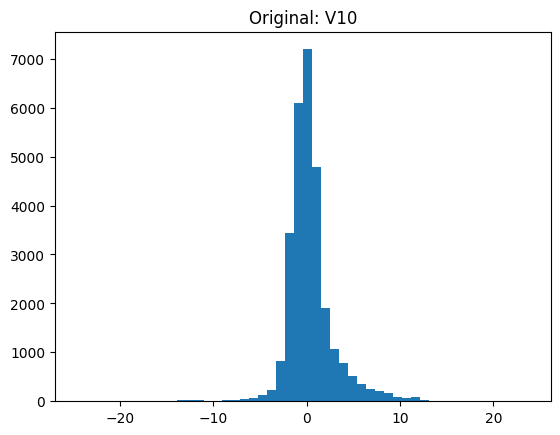

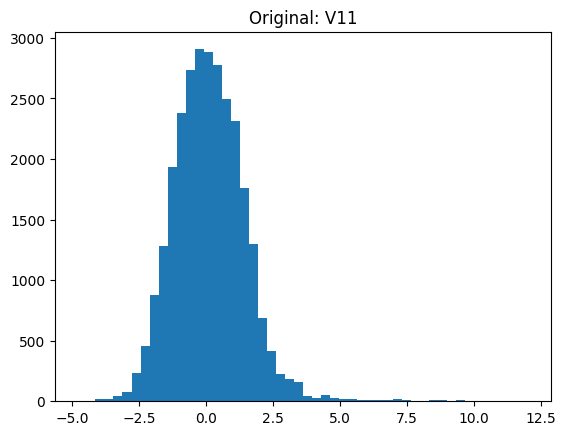

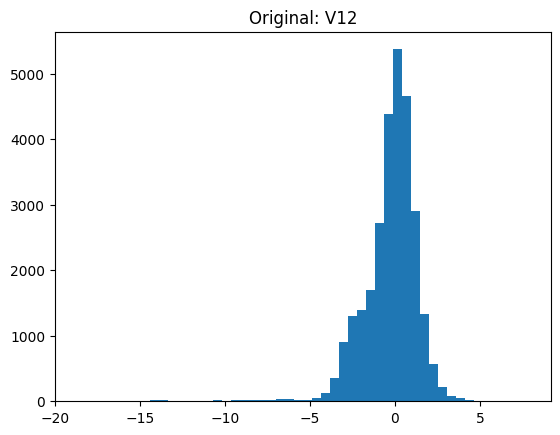

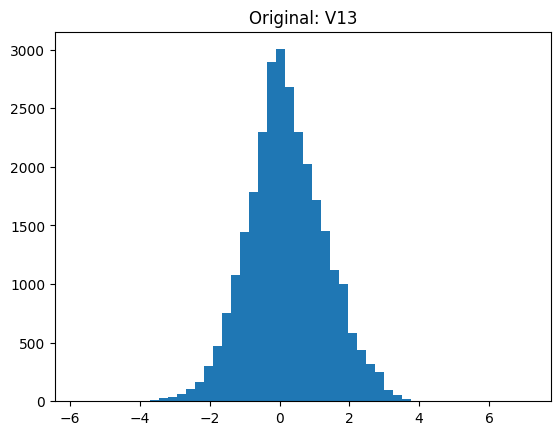

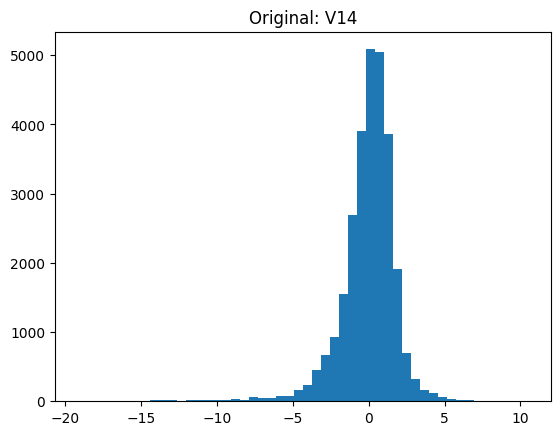

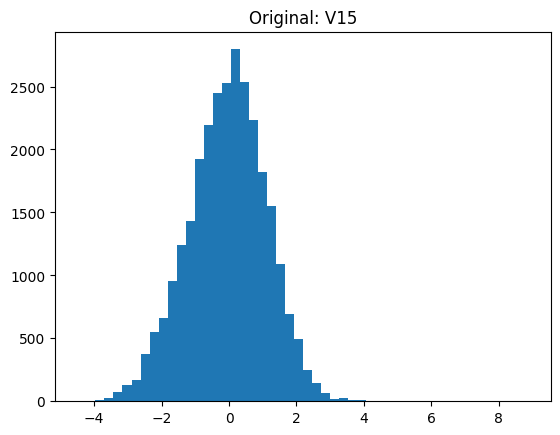

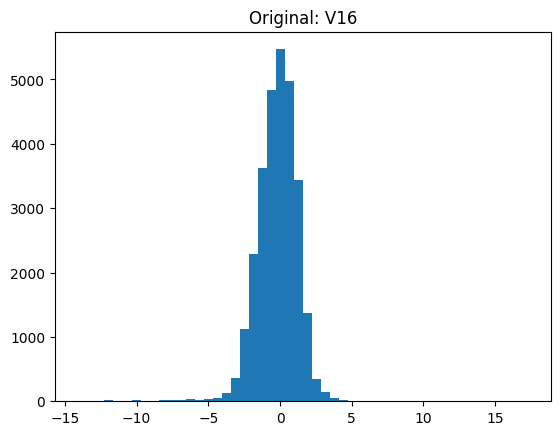

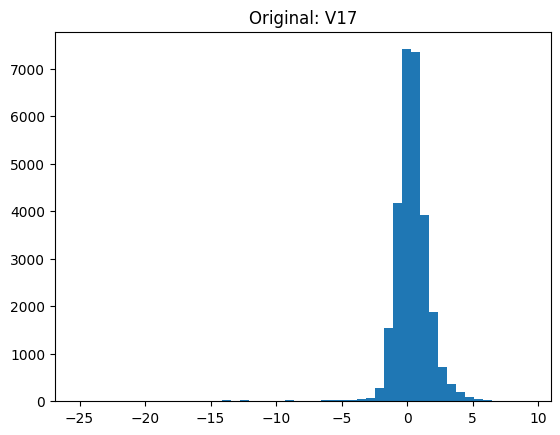

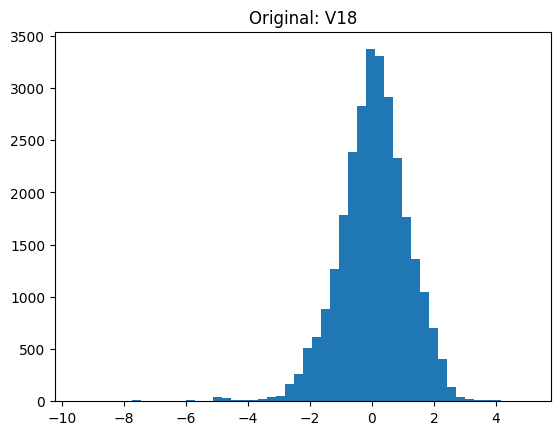

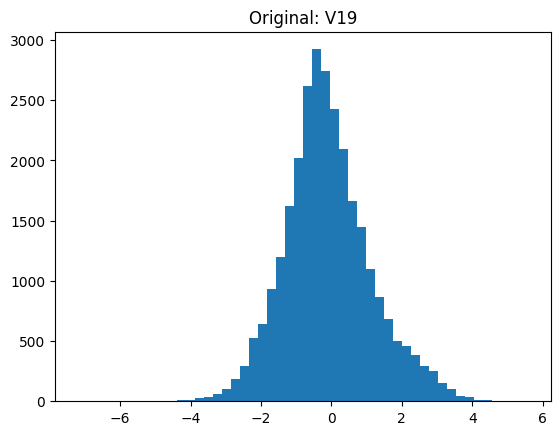

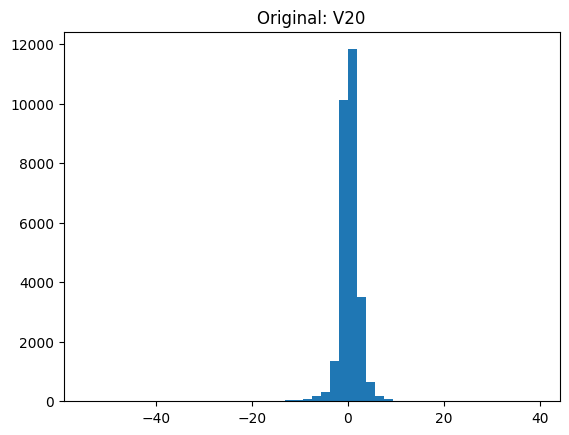

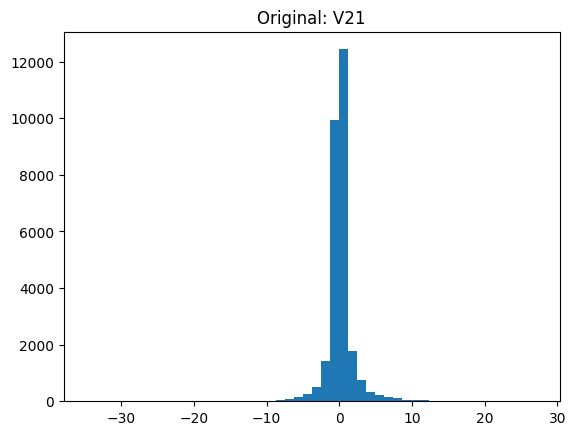

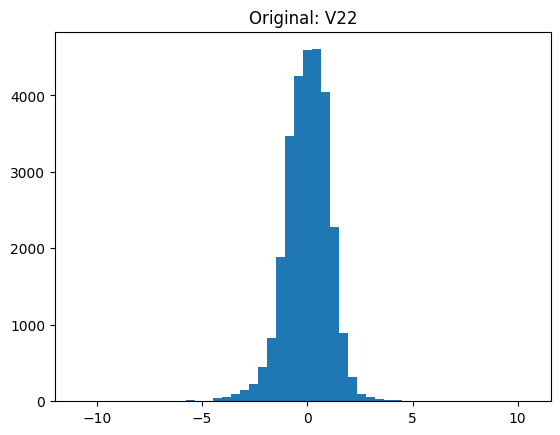

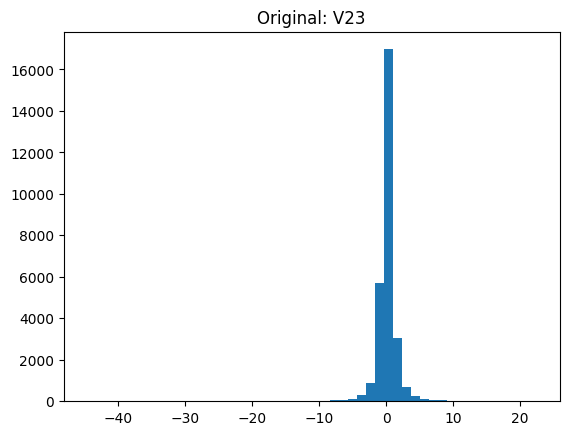

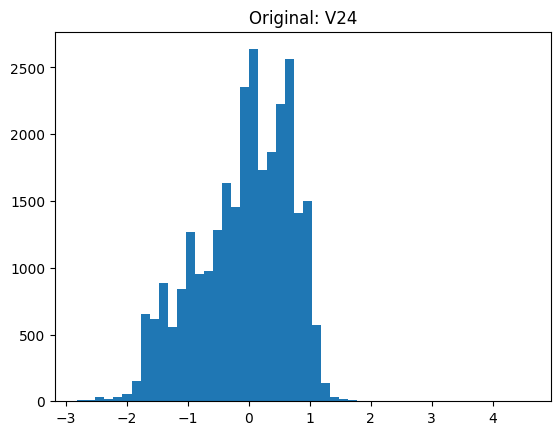

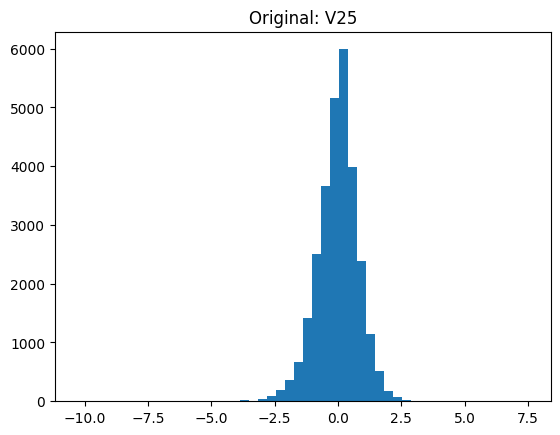

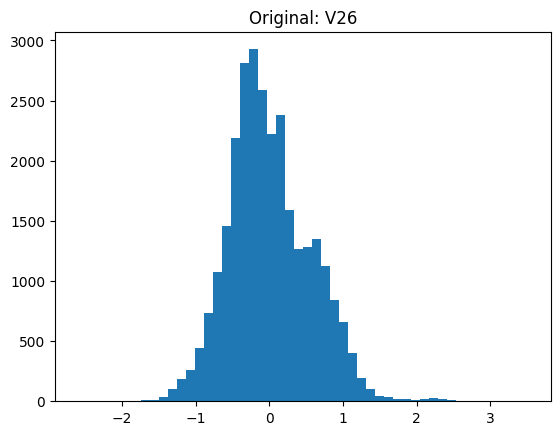

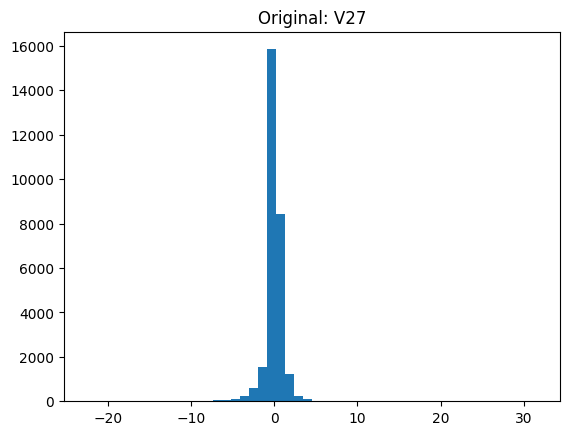

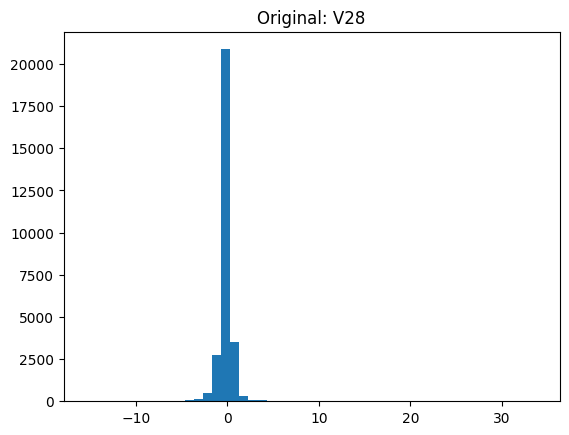

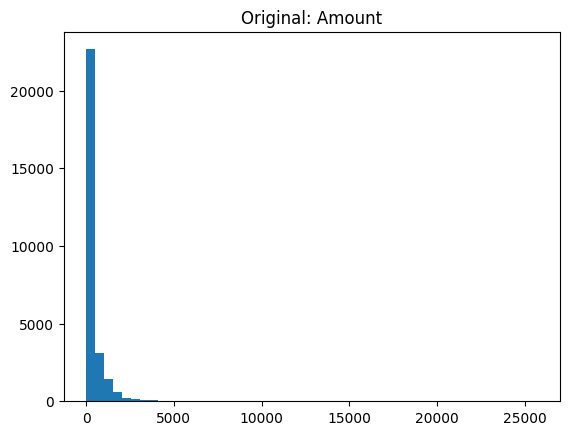

Transformed: Amount | Skewness before: 7.34, after: -0.03


In [7]:
skewed_cols = []
for col in features.columns:
    plt.figure()
    plt.hist(features[col], bins=50)
    plt.title(f"Original: {col}")
    plt.show()

    if features[col].min() >= 0:  
        transformed = np.log1p(features[col])
        skewness_before = features[col].skew()
        skewness_after = transformed.skew()

        if abs(skewness_after) < abs(skewness_before): 
            features[col] = transformed
            skewed_cols.append(col)
            print(f"Transformed: {col} | Skewness before: {skewness_before:.2f}, after: {skewness_after:.2f}")

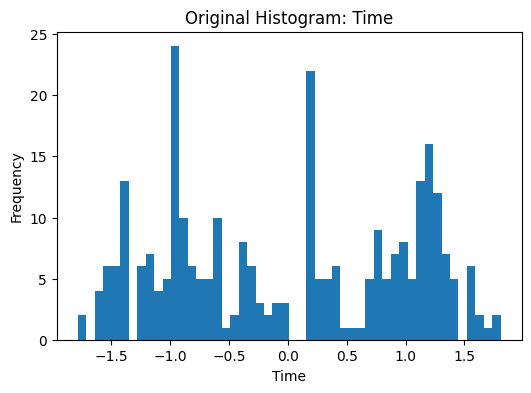

⚠️ Skipped Time because it has negative values.



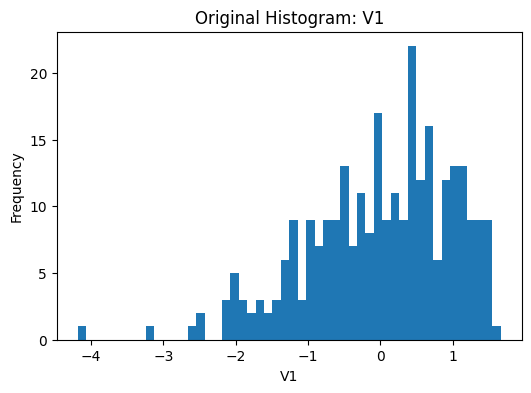

⚠️ Skipped V1 because it has negative values.



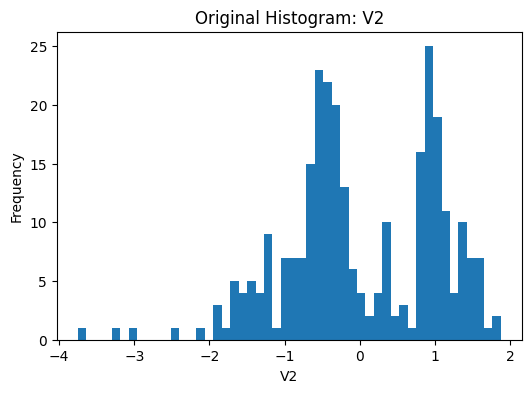

⚠️ Skipped V2 because it has negative values.



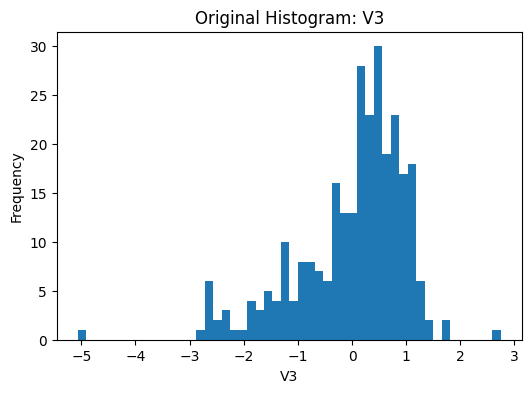

⚠️ Skipped V3 because it has negative values.



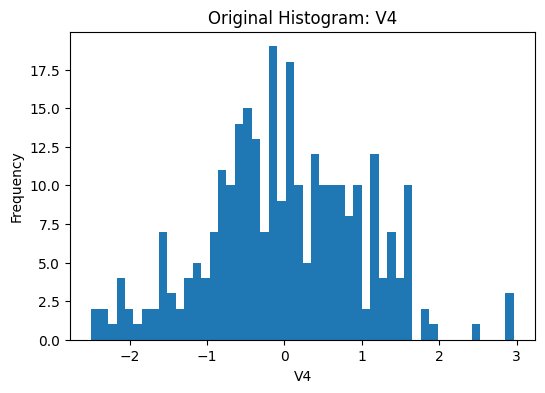

⚠️ Skipped V4 because it has negative values.



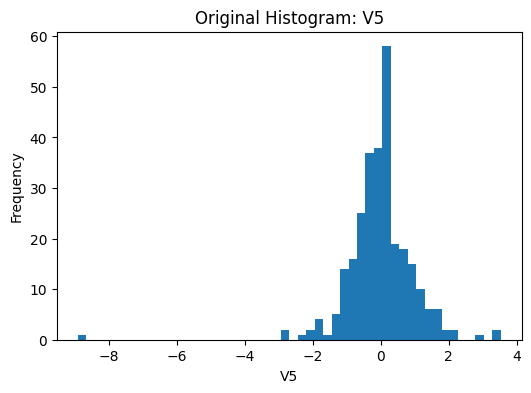

⚠️ Skipped V5 because it has negative values.



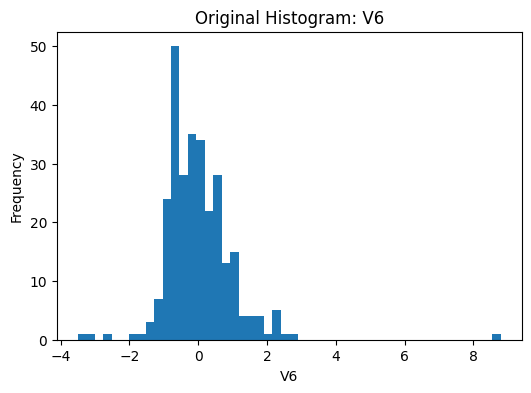

⚠️ Skipped V6 because it has negative values.



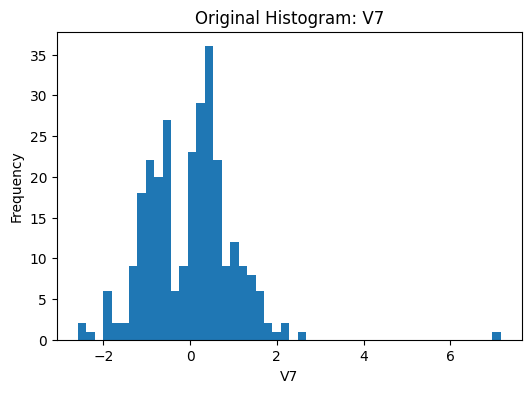

⚠️ Skipped V7 because it has negative values.



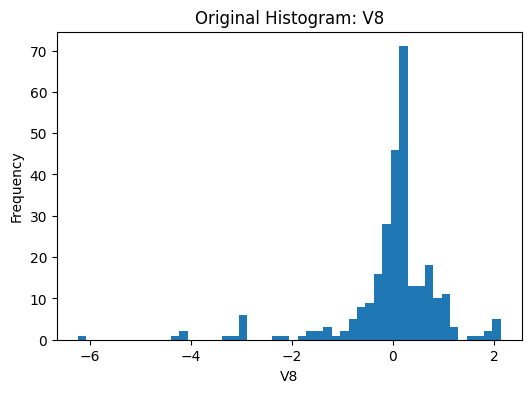

⚠️ Skipped V8 because it has negative values.



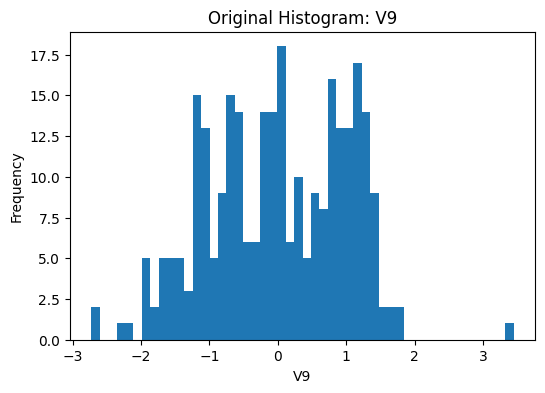

⚠️ Skipped V9 because it has negative values.



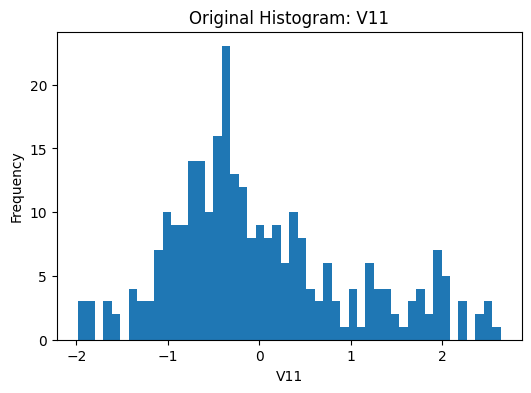

⚠️ Skipped V11 because it has negative values.



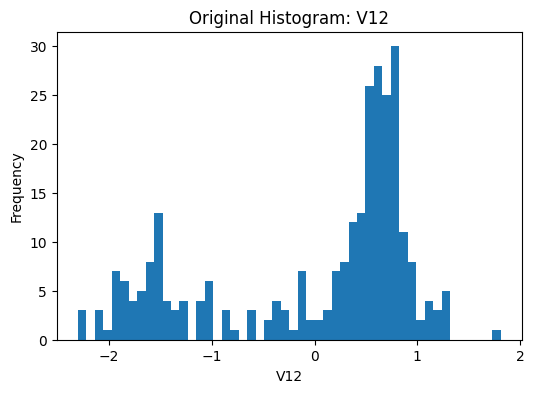

⚠️ Skipped V12 because it has negative values.



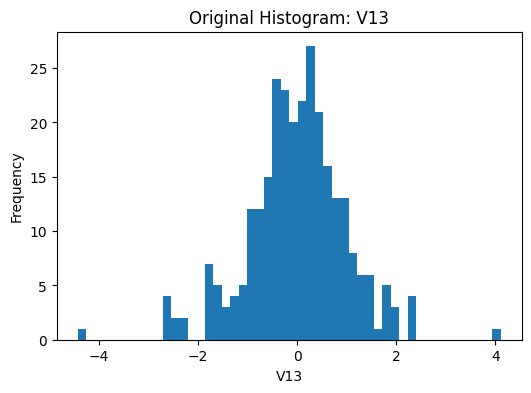

⚠️ Skipped V13 because it has negative values.



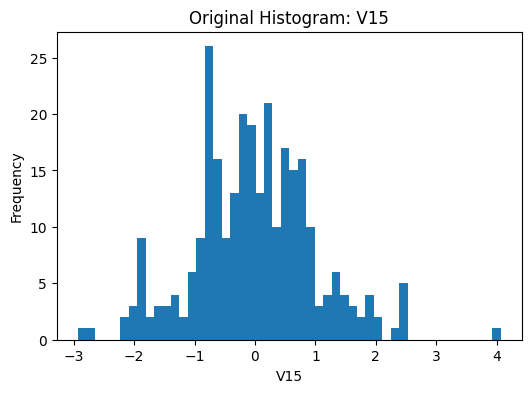

⚠️ Skipped V15 because it has negative values.



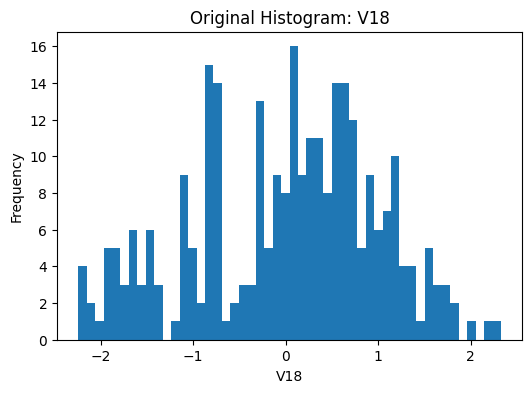

⚠️ Skipped V18 because it has negative values.



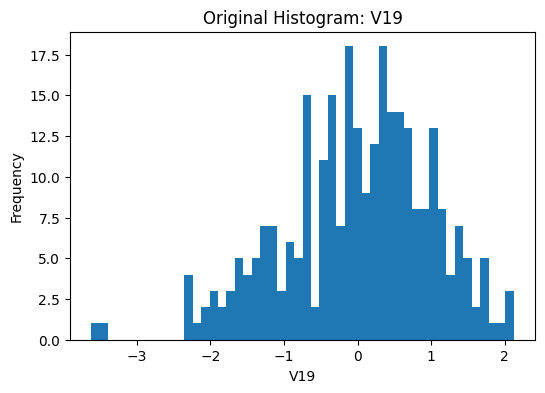

⚠️ Skipped V19 because it has negative values.



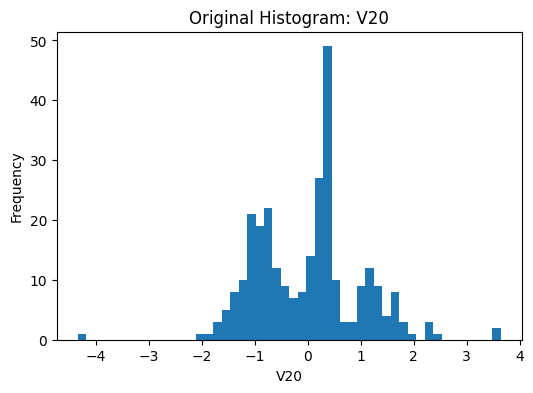

⚠️ Skipped V20 because it has negative values.



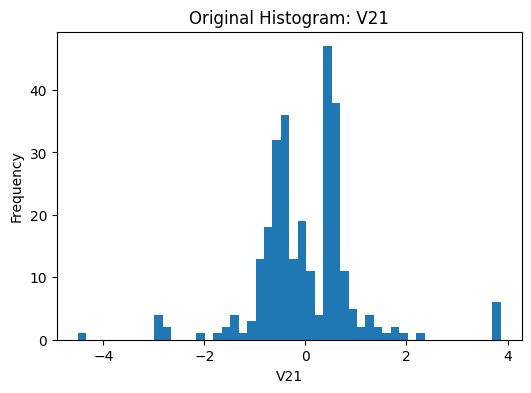

⚠️ Skipped V21 because it has negative values.



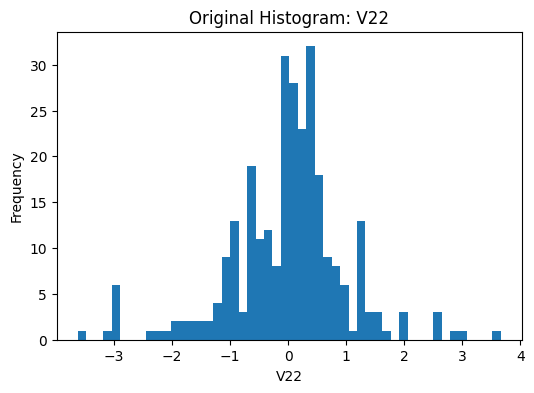

⚠️ Skipped V22 because it has negative values.



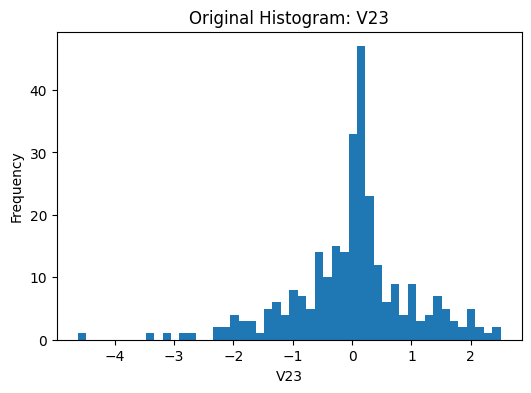

⚠️ Skipped V23 because it has negative values.



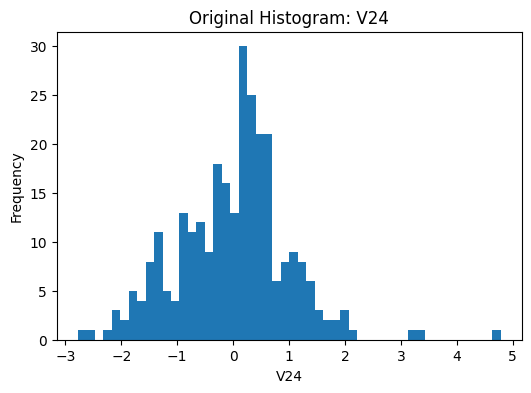

⚠️ Skipped V24 because it has negative values.



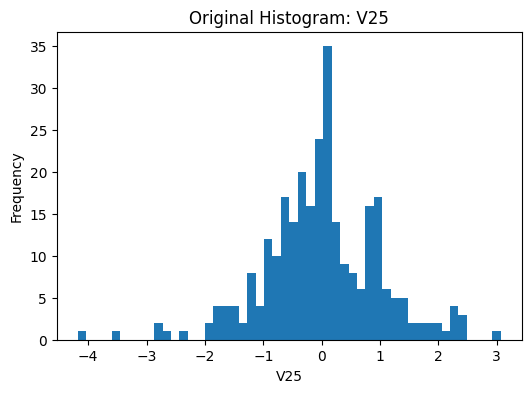

⚠️ Skipped V25 because it has negative values.



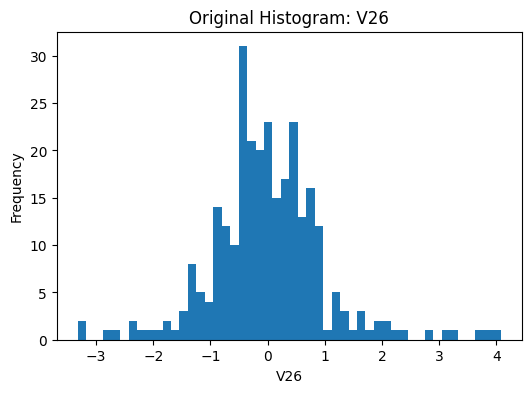

⚠️ Skipped V26 because it has negative values.



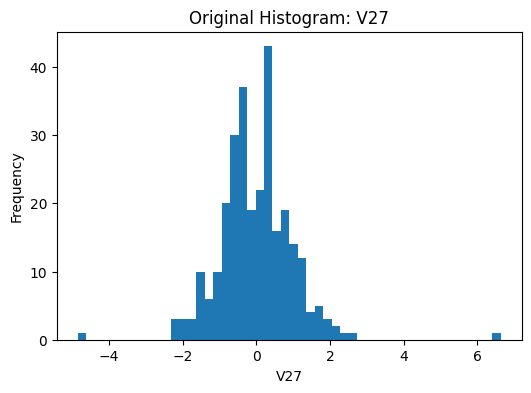

⚠️ Skipped V27 because it has negative values.



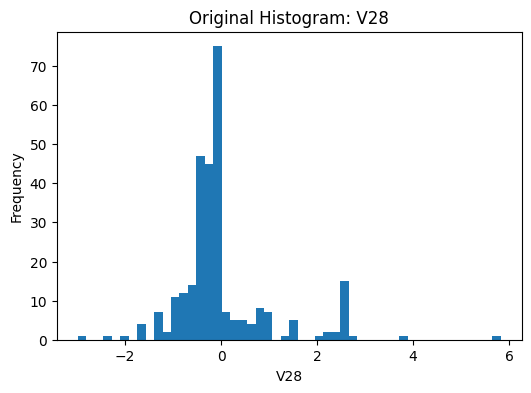

⚠️ Skipped V28 because it has negative values.



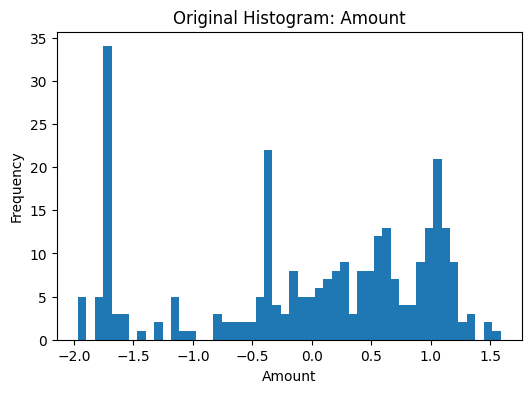

⚠️ Skipped Amount because it has negative values.

===== Final Summary =====
✅ Symmetric (log1p applied):

❌ Still Skewed or Skipped:


In [12]:
symmetric_cols = []    
still_skewed_cols = [] 
for col in features.columns:
    plt.figure(figsize=(6, 4))
    plt.hist(features[col], bins=50)
    plt.title(f"Original Histogram: {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    # Step 3: Check if it's safe to apply log1p (must be >= 0)
    if features[col].min() >= 0:
        # Apply log1p transformation
        transformed = np.log1p(features[col])

        # Calculate skewness before and after
        skew_before = features[col].skew()
        skew_after = transformed.skew()

        print(f"{col} - Skew Before: {skew_before:.2f}, Skew After: {skew_after:.2f}")

        # Step 4: If skew improved, update column
        if abs(skew_after) < abs(skew_before):
            features[col] = transformed
            symmetric_cols.append(col)
            print(f"✅ Transformed: {col} improved skewness.\n")
        else:
            still_skewed_cols.append(col)
            print(f"❌ Not transformed: {col} still skewed after log1p.\n")
    else:
        print(f"⚠️ Skipped {col} because it has negative values.\n")

# Step 5: Final Summary
print("===== Final Summary =====")
print("✅ Symmetric (log1p applied):")
for col in symmetric_cols:
    print("  -", col)

print("\n❌ Still Skewed or Skipped:")
for col in still_skewed_cols:
    print("  -", col)

In [8]:

selector = VarianceThreshold(threshold=0.01)
features_low_var = selector.fit_transform(features)
selected_features_var = features.columns[selector.get_support(indices=True)]

features = pd.DataFrame(features_low_var, columns=selected_features_var)


In [ ]:
# Remove high correlated features
corr_matrix = features.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.90)]

features.drop(columns=to_drop_corr, inplace=True)

In [10]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
features = pd.DataFrame(features_scaled, columns=features.columns)

In [11]:
final_df = pd.concat([features, df[target_cols].reset_index(drop=True)], axis=1)

In [12]:
print("Selected features after log transform, low variance, and correlation filtering:")
print(features.columns.tolist())

Selected features after log transform, low variance, and correlation filtering:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
